In [2]:
import os
import warnings
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap
from upsetplot import UpSet, from_contents

warnings.filterwarnings("ignore")

rcParams['ps.useafm'] = True
rcParams['pdf.use14corefonts'] = True
rcParams['pdf.fonttype'] = 42 
rcParams['ps.fonttype'] = 42


font_path = '/users/PCON0022/huchen/Arial.ttf'
fm.fontManager.addfont(font_path)
# Get the font name
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name


my_cmap = LinearSegmentedColormap.from_list(
    "soft_rdbl", ["#53b1dc", "#FFFFFF", "#EE6677"], N=256
)

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

In [3]:
sample_list = ['HCC1R', 'HCC2R', 'HCC4R', 'HCC5NR', 'HCC6NR', 'HCC7NR']
adata_dict = {}
lr_dict = {}

for sample in sample_list:
    res_dir = Path(f"/fs/ess/PAS1475/huchen/Diffusion/Liver_Visium/spaflow_results/{sample}")
    os.makedirs(res_dir, exist_ok=True)
    print(res_dir)
    adata = sc.read(res_dir / "downstream.h5ad")
    lr_df = pd.read_csv(res_dir / "filtered_secreted_LR_pairs.csv")
    adata_dict[sample] = adata
    lr_dict[sample] = lr_df

/fs/ess/PAS1475/huchen/Diffusion/Liver_Visium/spaflow_results/HCC1R
/fs/ess/PAS1475/huchen/Diffusion/Liver_Visium/spaflow_results/HCC2R
/fs/ess/PAS1475/huchen/Diffusion/Liver_Visium/spaflow_results/HCC4R
/fs/ess/PAS1475/huchen/Diffusion/Liver_Visium/spaflow_results/HCC5NR
/fs/ess/PAS1475/huchen/Diffusion/Liver_Visium/spaflow_results/HCC6NR
/fs/ess/PAS1475/huchen/Diffusion/Liver_Visium/spaflow_results/HCC7NR


In [4]:
# minimum number of hotspots = 10
sample_sets = {}
for sample, lr in lr_dict.items():
    obs = adata_dict[sample].obs

    keep_complex = [
        c for c in lr['complex']
        if f"{c}_sig" in obs.columns and obs[f"{c}_sig"].sum() > 10
    ]

    print(sample, len(keep_complex))
    print(keep_complex)
    sample_sets[sample] = set(keep_complex)

upset_data = from_contents(sample_sets)



HCC1R 7
['CXCL12-CXCR4', 'MIF-CD74_CXCR4', 'MIF-CD74_CD44', 'SPP1-CD44', 'ANGPTL4-SDC1', 'ANGPTL4-SDC2', 'ANGPTL4-SDC4']
HCC2R 8
['CXCL12-CXCR4', 'MIF-CD74_CXCR4', 'MIF-CD74_CD44', 'SPP1-CD44', 'F2-F2R', 'PLG-F2R', 'LGALS9-PTPRC', 'LGALS9-CD44']
HCC4R 5
['CXCL12-CXCR4', 'MDK-SDC1', 'MDK-SDC2', 'MDK-LRP1', 'MDK-NCL']
HCC5NR 4
['MDK-SDC1', 'MDK-SDC2', 'MDK-LRP1', 'MDK-NCL']
HCC6NR 4
['MDK-SDC1', 'MDK-SDC2', 'MDK-SDC4', 'MDK-NCL']
HCC7NR 3
['ANGPTL4-SDC1', 'ANGPTL4-SDC2', 'ANGPTL4-SDC4']


## Fig. 3a

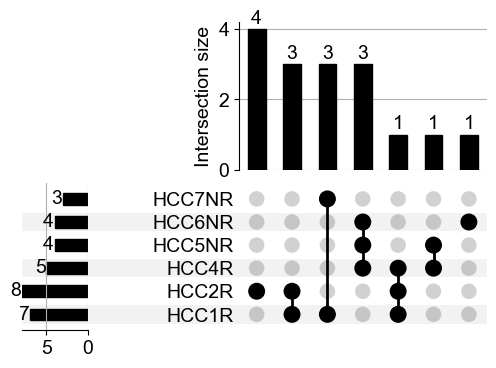

In [5]:
with plt.rc_context({'font.size': 14}):
    up = UpSet(
        upset_data,
        subset_size='count',
        show_counts=True,
        sort_by='cardinality',
        sort_categories_by=None
    )

    up.plot()
    fig = plt.gcf()
    fig.set_size_inches(6, 4)
    plt.show()


## Fig. 3b

In [6]:
R_dict = {}
R_dict['HCC1R'] = adata_dict['HCC1R']
R_dict['HCC2R'] = adata_dict['HCC2R']
R_dict['HCC4R'] = adata_dict['HCC4R']

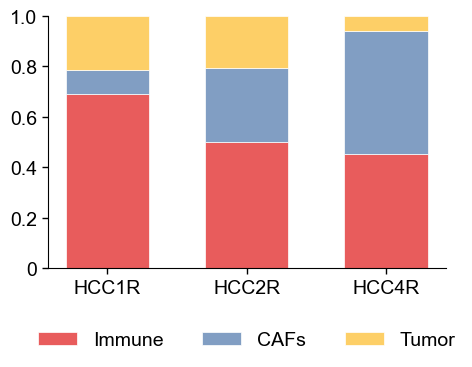

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

records = []
for sample, adata in R_dict.items():
    mask = adata.obs['CXCL12-CXCR4_sig'] == True
    props = adata.obs.loc[mask, 'primary_label'].value_counts(normalize=True)
    for label, val in props.items():
        records.append({'sample': sample, 'primary_label': label, 'proportion': val})

df = pd.DataFrame(records)

pivot = df.pivot_table(
    index='sample',
    columns='primary_label',
    values='proportion',
    fill_value=0
)
pivot = pivot.loc[sorted(pivot.index)]

labels = ['Immune', 'CAFs', 'Tumor']
colors = {'Immune': '#E85C5C', 'CAFs': '#819ec3', 'Tumor': '#fdcf67'}

with plt.rc_context({'font.size': 14}):
    fig, ax = plt.subplots(figsize=(5, 4))
    bottom = np.zeros(len(pivot))

    for lbl in labels:
        vals = pivot[lbl].values if lbl in pivot.columns else np.zeros(len(pivot))
        ax.bar(
            pivot.index, vals, bottom=bottom,
            color=colors[lbl], label=lbl,
            width=0.6, edgecolor='white', linewidth=0.5
        )
        bottom += vals

    ax.set_ylabel('')
    ax.set_ylim(0, 1.0)
    ax.set_xlabel('')
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_yticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.tick_params(axis='y', length=4)
    ax.set_xticks(np.arange(len(pivot.index)))
    # ax.set_xticklabels(pivot.index, fontsize=9)

    ax.legend(
        title='',
        loc='upper center',
        bbox_to_anchor=(0.5, -0.18),
        ncol=3,
        frameon=False
    )

    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', which='both', left=True, right=False, length=4, width=1, color='black')
    ax.tick_params(axis='x', which='both', bottom=True, top=False, length=4, width=1, color='black')

    plt.tight_layout()
    # plt.savefig('CXCL12_CXCR4_sig_proportion_R.pdf', bbox_inches='tight')
    plt.show()


## Fig. 3d and Supplementary Fig. 3

In [8]:
from scipy.stats import fisher_exact
import numpy as np
import pandas as pd
import scipy.sparse as sparse

n_hops = 3

boundary_results = []
for sample, adata in R_dict.items():
    graph = adata.obsp['spatial_connectivities']
    graph = (graph + graph.T)
    graph.data[:] = 1
    graph = graph.astype(np.uint8)

    n = adata.n_obs
    if n < 5:
        print(f"[skip] {sample}: too few spots")
        continue

    tumor = adata.obs['primary_label'].eq('Tumor').values
    non_tumor = ~tumor
    if tumor.sum() < 3:
        print(f"[skip] {sample}: <3 tumor spots")
        continue

    boundary_seed = non_tumor & (graph.dot(tumor.astype(np.uint8)) > 0)
    boundary_zone = boundary_seed.copy()
    frontier = boundary_seed.copy()
    for _ in range(max(0, n_hops - 1)):
        next_frontier = (graph.dot(frontier.astype(np.uint8)) > 0) & ~boundary_zone & ~tumor
        boundary_zone |= next_frontier
        frontier = next_frontier

    immune_sig = (
        adata.obs['primary_label'].eq('Immune').values &
        adata.obs['CXCL12-CXCR4_sig'].eq(True).values
    )

    adata.obs['tumor_boundary_hops'] = pd.Categorical(
        np.where(boundary_zone, 'Boundary', 'Non-boundary')
    )
    print(adata.obs['tumor_boundary_hops'].value_counts())
    adata.obs['immune_cxcl12_cxcr4_sig'] = pd.Categorical(
        np.where(immune_sig, 'Immune_sig', 'Other')
    )

    a = int((immune_sig & boundary_zone).sum())
    b = int((~immune_sig & boundary_zone).sum())
    c = int((immune_sig & ~boundary_zone & ~tumor).sum())
    d = int((~immune_sig & ~boundary_zone & ~tumor).sum())
    odds_ratio, p_value = fisher_exact([[a, b], [c, d]], alternative='greater')

    boundary_results.append({
        'sample': sample,
        'immune_sig_boundary': a,
        'immune_sig_nonboundary': c,
        'boundary_total': int(boundary_zone.sum()),
        'nonboundary_total': int((~boundary_zone & ~tumor).sum()),
        'boundary_fraction': a / max(1, int(boundary_zone.sum())),
        'nonboundary_fraction': c / max(1, int((~boundary_zone & ~tumor).sum())),
        'odds_ratio': odds_ratio,
        'p_value': p_value,
    })

boundary_results = pd.DataFrame(boundary_results).sort_values('p_value')
boundary_results


tumor_boundary_hops
Non-boundary    1693
Boundary        1021
Name: count, dtype: int64
tumor_boundary_hops
Boundary        1302
Non-boundary    1049
Name: count, dtype: int64
tumor_boundary_hops
Non-boundary    2100
Boundary         900
Name: count, dtype: int64


,sample,immune_sig_boundary,immune_sig_nonboundary,boundary_total,nonboundary_total,boundary_fraction,nonboundary_fraction,odds_ratio,p_value
1,HCC2R,29,0,1302,48,0.022273,0.000000,inf,0.346062
0,HCC1R,28,1,1021,62,0.027424,0.016129,1.720040,0.496893
2,HCC4R,42,18,900,32,0.046667,0.562500,0.038073,1.000000


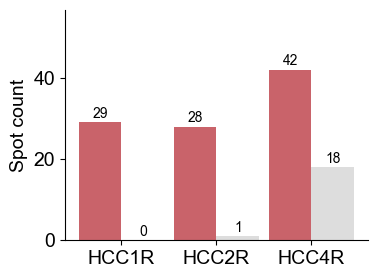

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

samples = ['HCC1R', 'HCC2R', 'HCC4R']
boundary_counts = list(boundary_results['immune_sig_boundary'])
nonboundary_counts = list(boundary_results['immune_sig_nonboundary'])
p_values = list(boundary_results['p_value'])

def fmt_p(p):
    if p < 0.001:
        return f'p={p:.1e}'
    return f'p={p:.3f}'

x = np.arange(len(samples))
width = 0.45

with plt.rc_context({'font.size': 14}):

    fig, ax = plt.subplots(figsize=(4, 3))
    
    bars1 = ax.bar(x - width/2, boundary_counts, width, label='Boundary',
                  color='#c9636a')
    bars2 = ax.bar(x + width/2, nonboundary_counts, width, label='Non-boundary',
                  color='#dddddd')
    # value labels on bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
    
    ax.set_xticks(x)
    ax.set_xticklabels(samples)
    ax.set_xlabel('')
    ax.set_ylabel('Spot count')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, max(boundary_counts) * 1.35)
    
    plt.tight_layout()
    plt.show()


In [10]:
for R_adata in R_dict.values():
    R_adata.uns['primary_label_colors'] = ['#E85C5C', '#819ec3', '#fdcf67']
    R_adata.obs['primary_label'] = pd.Categorical(
        R_adata.obs['primary_label'],
        categories=['Immune', 'CAFs', 'Tumor']
    )
    R_adata.obs['CXCL12-CXCR4_sig_str'] = R_adata.obs['CXCL12-CXCR4_sig'].map(
    {True: 'hotspot', False:'non-hotspot'})
    R_adata.uns['CXCL12-CXCR4_sig_str_colors'] = ["#EE6677", "#DDDDDD"]
    R_adata.uns['tumor_boundary_hops_colors'] = ["#c9636a", "#dddddd"]

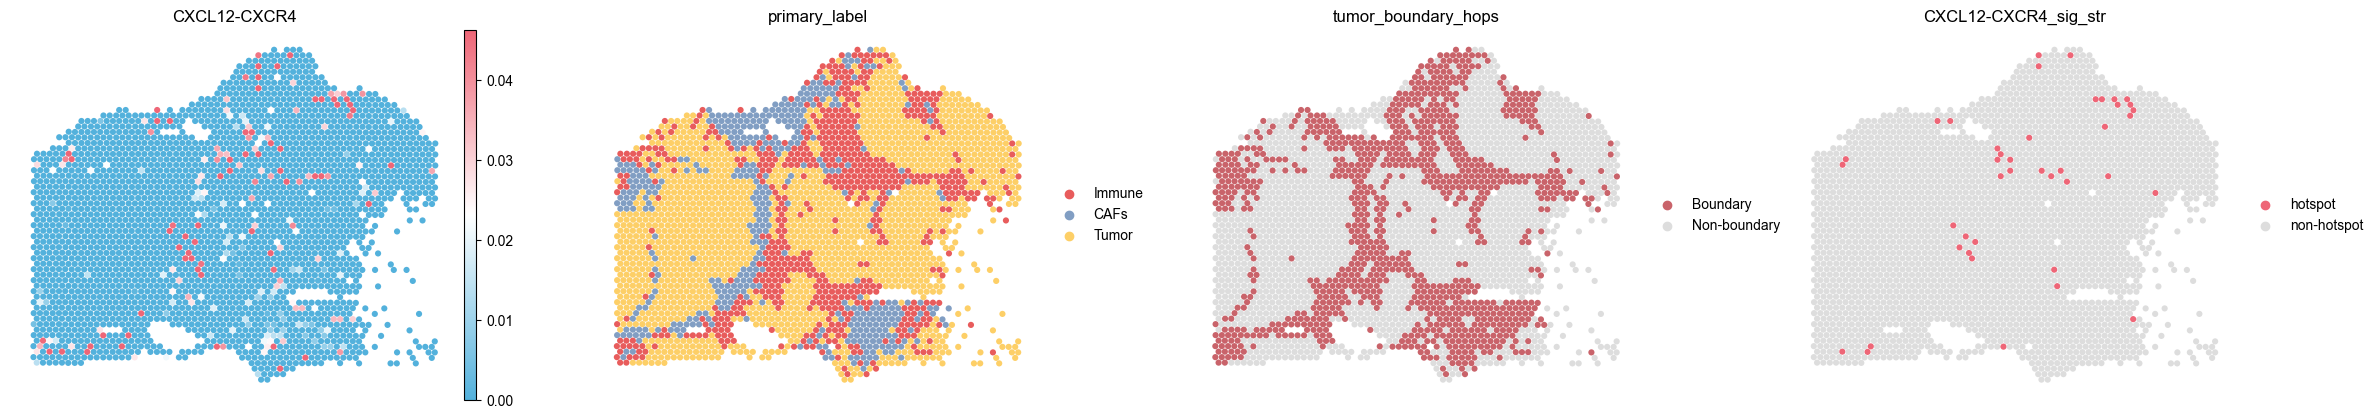

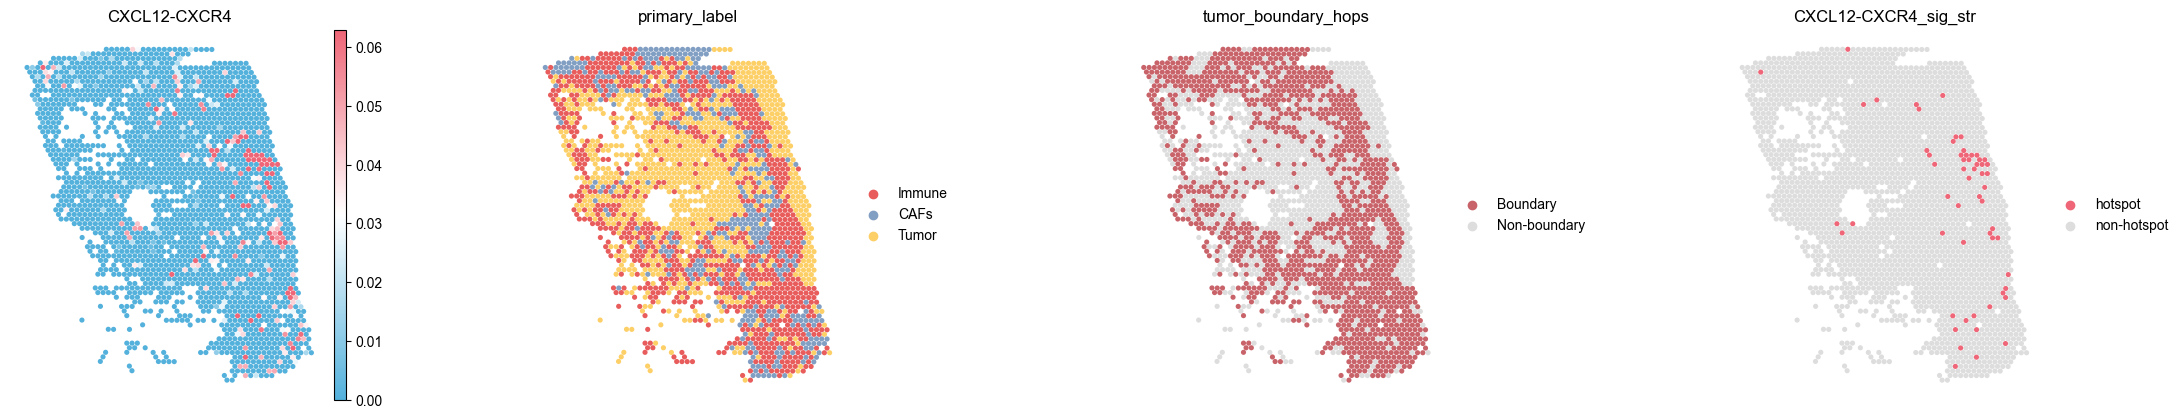

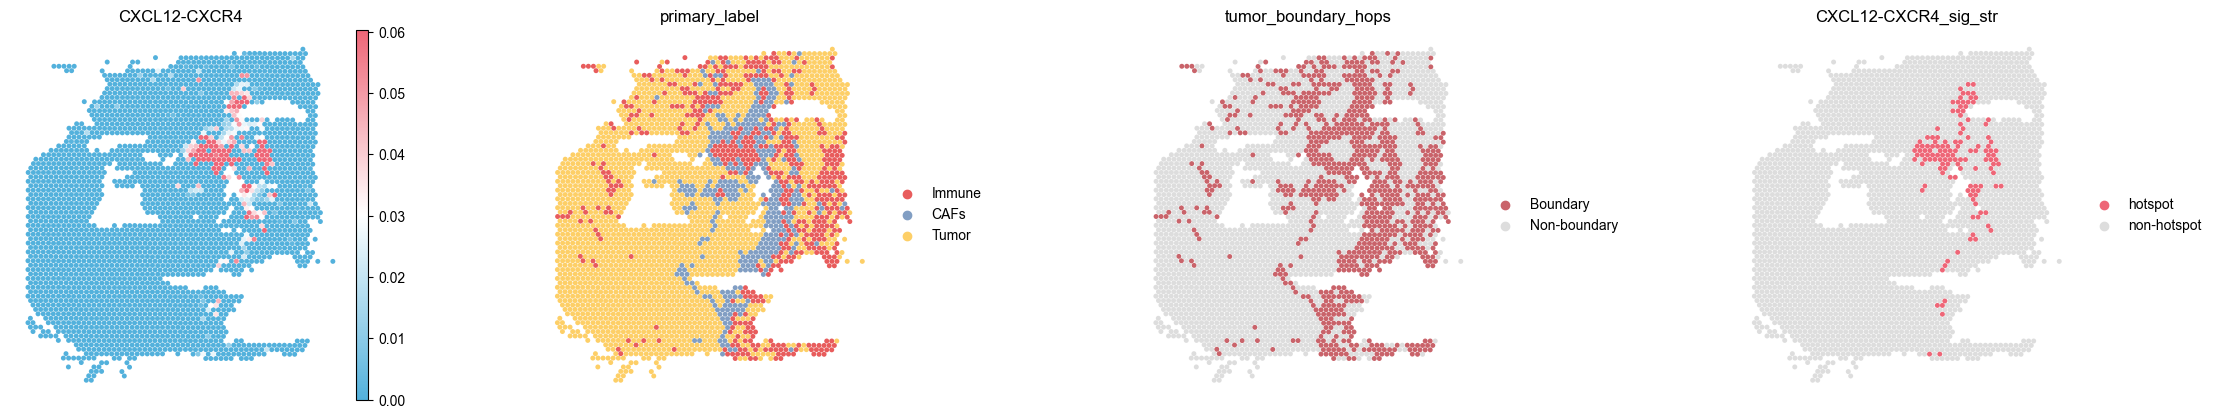

In [11]:
plot_keys = ['CXCL12-CXCR4', 'primary_label', 'tumor_boundary_hops', 'CXCL12-CXCR4_sig_str']
for sample, R_adata in R_dict.items():
    sc.pl.spatial(R_adata, color=plot_keys,  img_key=None,
                size=1.5,
                frameon=False,
                cmap=my_cmap,
                vmax='p98')

## Fig. 3d and Fig. 3e

In [12]:
t_cell_signature = [
    "CD3D", "CD3E", "CD3G", "CD2", "CD28", "TRAC",
    "CD8A", "CD8B", "GZMA", "GZMB", "PRF1",
    "CD4", "ICOS", "BATF", "IFNG", "IL17A",
    "FOXP3", "IL2RA",
    "CD96", "CYTIP", "TMSB4X"
]
t_cell_signature = [g for g in t_cell_signature if g in R_adata.var_names]
agpres_genes = ['B2M','CALR','CANX','CD4','CD74','CD8A','CD8B','CIITA','CREB1','CTSB','CTSL','CTSS','HLA-A','HLA-B','HLA-C','HLA-DMA','HLA-DMB','HLA-DOA','HLA-DOB','HLA-DPA1','HLA-DPB1','HLA-DQA1','HLA-DQA2','HLA-DQB1','HLA-DRA','HLA-DRB1','HLA-DRB3','HLA-DRB4','HLA-DRB5','HLA-E','HLA-F','HLA-G','HSP90AA1','HSP90AB1','HSPA1A','HSPA1B','HSPA1L','HSPA2',
                       'HSPA4','HSPA5','HSPA6','HSPA8','IFI30','IFNA1','IFNA10','IFNA13','IFNA14','IFNA16',
                       'IFNA17','IFNA2','IFNA21','IFNA4','IFNA5','IFNA6','IFNA7','IFNA8','KIR2DL1','KIR2DL2',
                       'KIR2DL3','KIR2DL4','KIR2DL5A','KIR2DS1','KIR2DS3','KIR2DS4','KIR2DS5','KIR3DL1','KIR3DL2','KIR3DL3','KLRC1','KLRC2','KLRC3','KLRC4','KLRD1','LGMN','LTA','NFYA','NFYB','NFYC','PDIA3','PSME1','PSME2','PSME3','RFX5','RFXANK','RFXAP','TAP1','TAP2','TAPBP']
agpres_genes = [g for g in agpres_genes if g in R_adata.var_names]

for sample, adata in R_dict.items():
    sc.tl.score_genes(adata, gene_list=agpres_genes, score_name='AgPres')
    sc.tl.score_genes(adata, gene_list=t_cell_signature, score_name='T cells')
    R_dict[sample] = adata

computing score 'AgPres'
    finished: added
    'AgPres', score of gene set (adata.obs).
    847 total control genes are used. (0:00:00)
computing score 'T cells'
    finished: added
    'T cells', score of gene set (adata.obs).
    650 total control genes are used. (0:00:00)
computing score 'AgPres'
    finished: added
    'AgPres', score of gene set (adata.obs).
    649 total control genes are used. (0:00:00)
computing score 'T cells'
    finished: added
    'T cells', score of gene set (adata.obs).
    600 total control genes are used. (0:00:00)
computing score 'AgPres'
    finished: added
    'AgPres', score of gene set (adata.obs).
    749 total control genes are used. (0:00:00)
computing score 'T cells'
    finished: added
    'T cells', score of gene set (adata.obs).
    648 total control genes are used. (0:00:00)


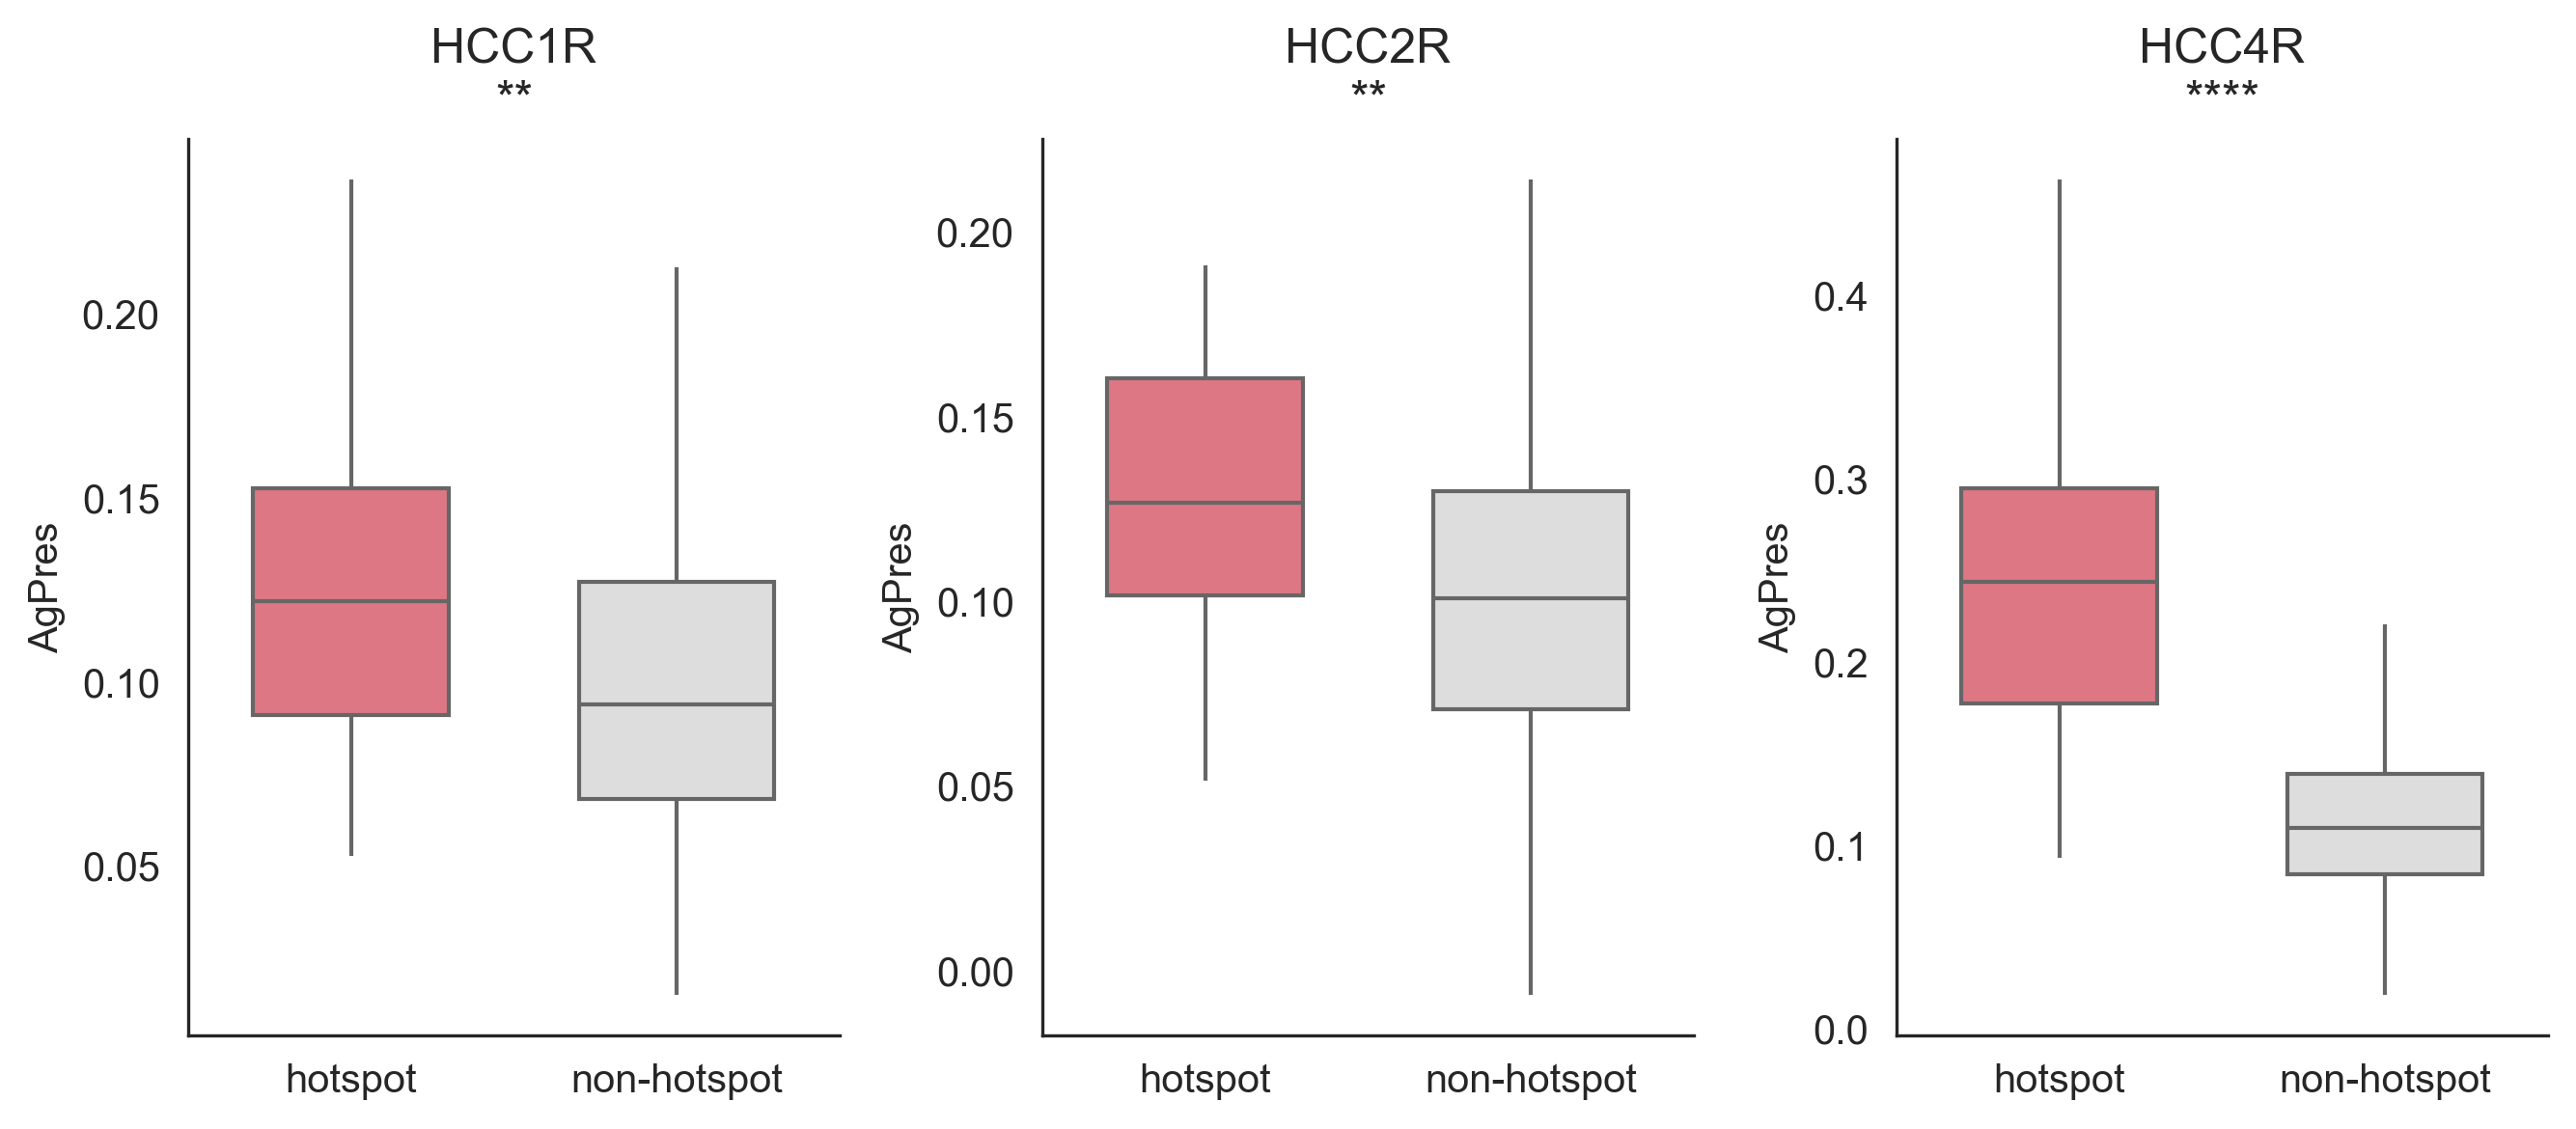

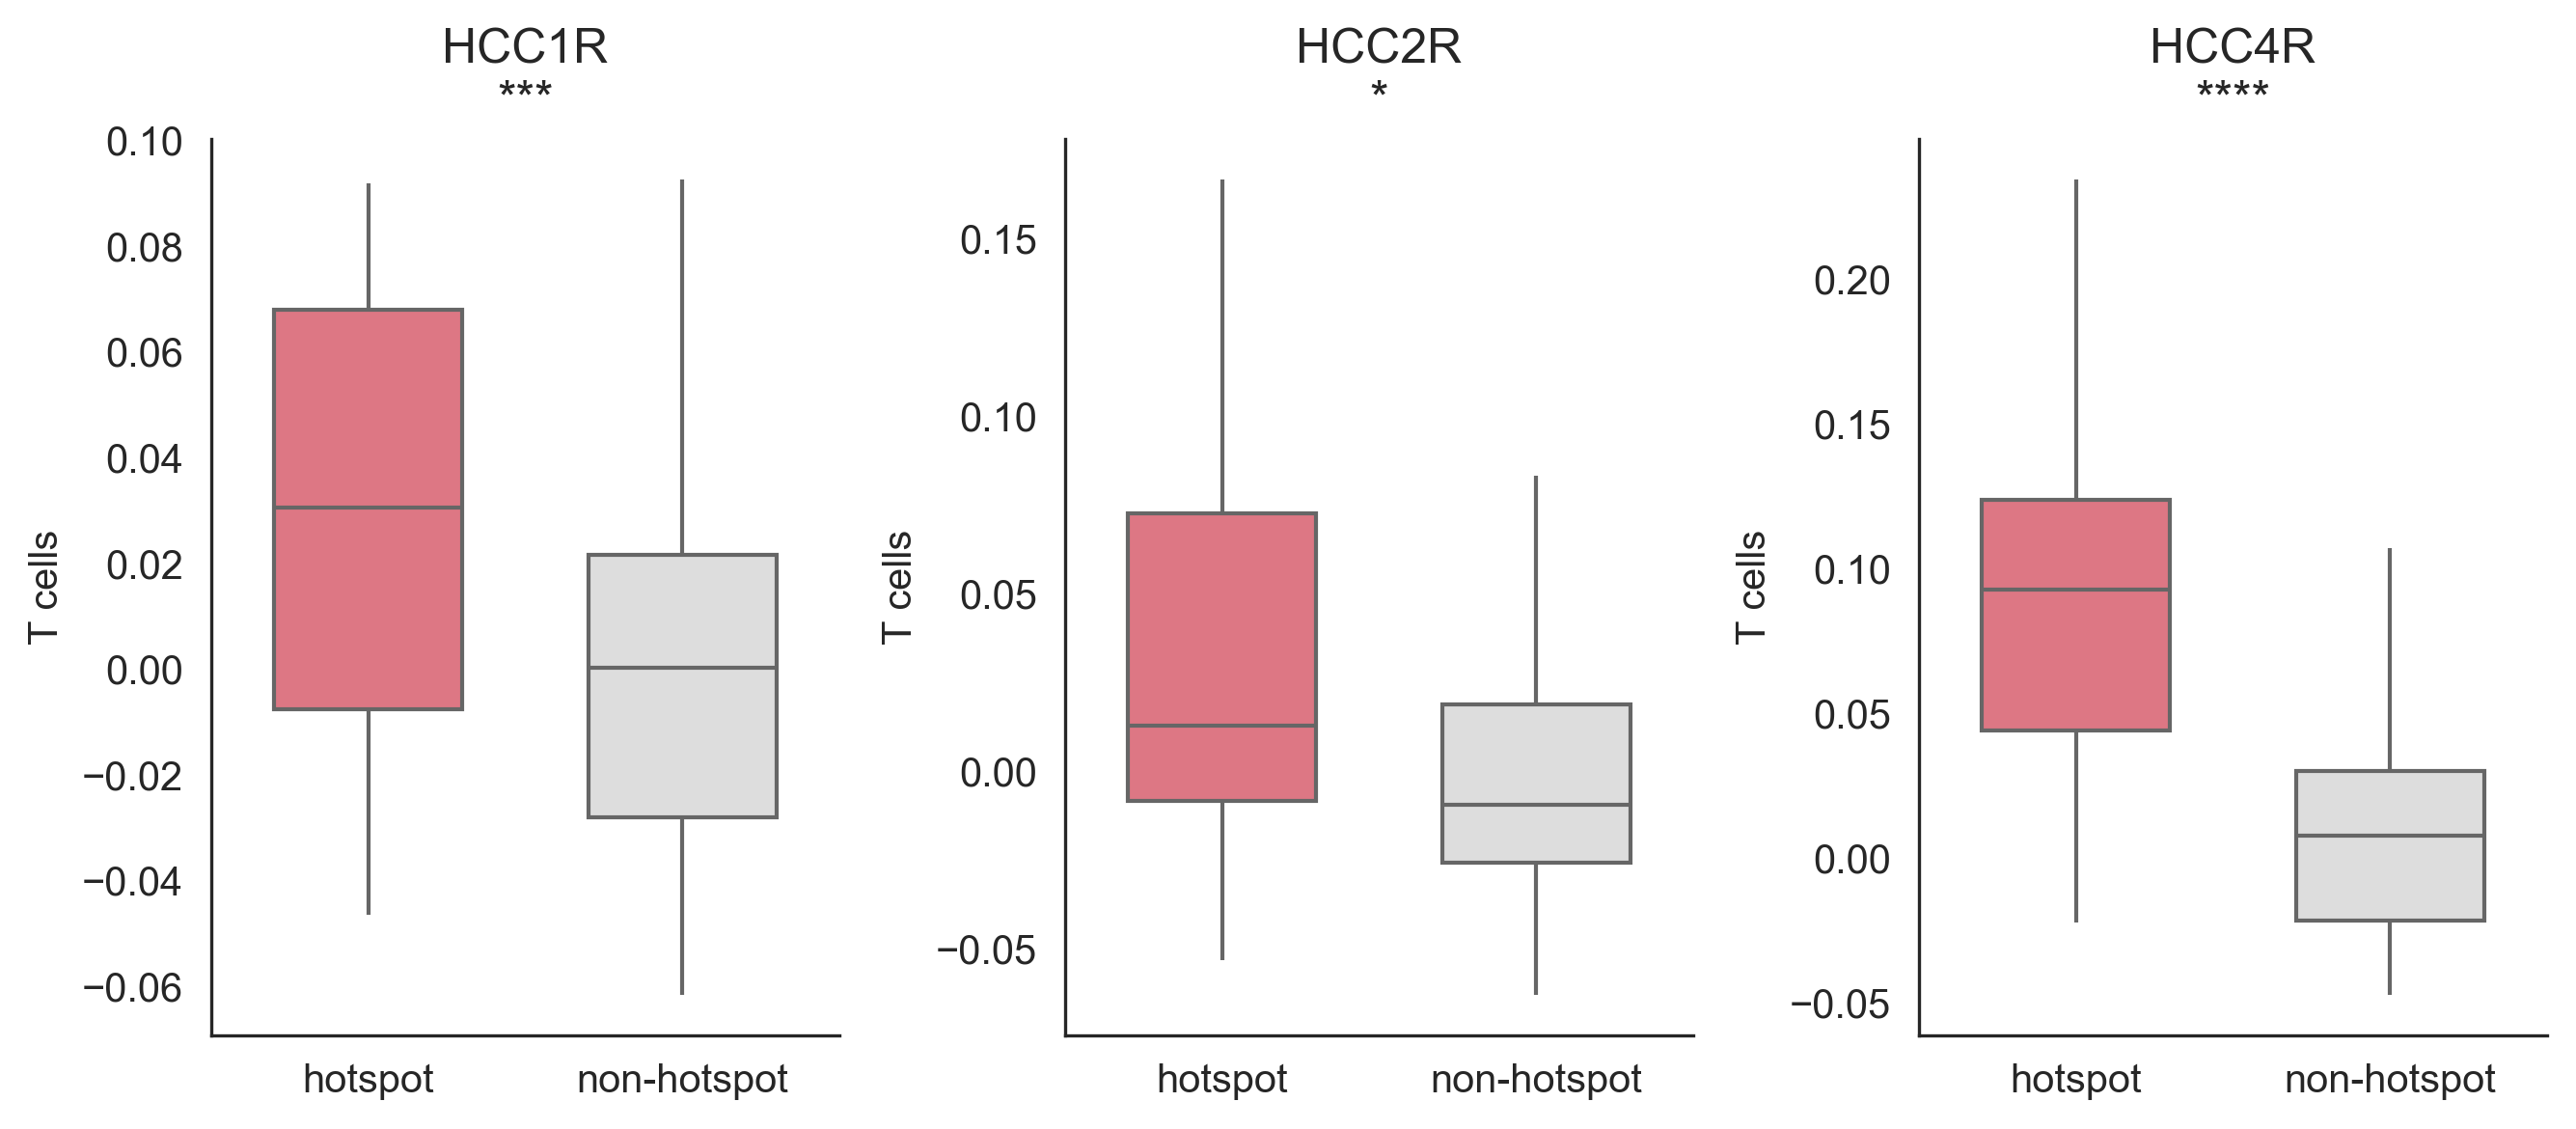

In [13]:
from scipy.stats import mannwhitneyu, kruskal
import seaborn as sns

sns.set_style('white')

def p_to_stars(p):
    if pd.isna(p):
        return 'NA'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 5e-2:
        return '*'
    return 'ns'

def plot_score_by_cxcl12_group(score_name, cell_type='Immune'):
    items = list(R_dict.items())
    fig, axes = plt.subplots(1, len(items), figsize=(3 * len(items), 4), dpi=300, squeeze=False)
    group_order = ['hotspot', 'non-hotspot']
    palette = {'hotspot': '#EE6677', 'non-hotspot': '#DDDDDD'}

    for ax, (sample, R_adata) in zip(axes[0], items):
        plot_adata = R_adata
        if cell_type is not None:
            plot_adata = plot_adata[plot_adata.obs['primary_label'] == cell_type]

        plot_df = plot_adata.obs[['CXCL12-CXCR4_sig_str', score_name]].dropna()
        plot_df['CXCL12-CXCR4_sig_str'] = pd.Categorical(
            plot_df['CXCL12-CXCR4_sig_str'],
            categories=group_order,
            ordered=True
        )
        plot_df = plot_df.sort_values('CXCL12-CXCR4_sig_str')
        groups = [
            plot_df.loc[plot_df['CXCL12-CXCR4_sig_str'] == group, score_name].values
            for group in group_order
            if group in plot_df['CXCL12-CXCR4_sig_str'].dropna().unique()
        ]

        p = np.nan
        if len(groups) == 2:
            _, p = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        elif len(groups) > 2:
            _, p = kruskal(*groups)

        sns.boxplot(
            data=plot_df,
            x='CXCL12-CXCR4_sig_str',
            y=score_name,
            order=group_order,
            palette=palette,
            showfliers=False,
            showcaps=False,
            width=0.6,
            ax=ax
        )
        ax.grid(False)
        sns.despine(ax=ax)
        ax.set_xlabel('')
        ax.set_ylabel(score_name)
        stat_text = p_to_stars(p) if len(groups) >= 2 else 'NA'
        ax.set_title(f"{sample}\n{stat_text}")

    plt.tight_layout()
    plt.show()

for score_name in ['AgPres', 'T cells']:
    plot_score_by_cxcl12_group(score_name)